Files found: ['friday.csv', 'monday.csv', 'thursday.csv', 'tuesday.csv', 'wednesday.csv']

Processing friday.csv...

Processing monday.csv...

Processing thursday.csv...

Processing tuesday.csv...

Processing wednesday.csv...

All files processed!
Final dataset shape: (88000, 89)

===== RANDOM FOREST =====
Accuracy: 0.9997727272727273
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13429
           1       1.00      1.00      1.00      4171

    accuracy                           1.00     17600
   macro avg       1.00      1.00      1.00     17600
weighted avg       1.00      1.00      1.00     17600



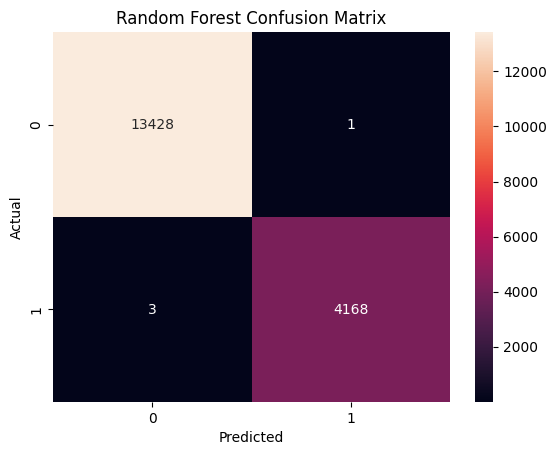

c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:21:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBOOST =====
Accuracy: 0.9998863636363636
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13429
           1       1.00      1.00      1.00      4171

    accuracy                           1.00     17600
   macro avg       1.00      1.00      1.00     17600
weighted avg       1.00      1.00      1.00     17600



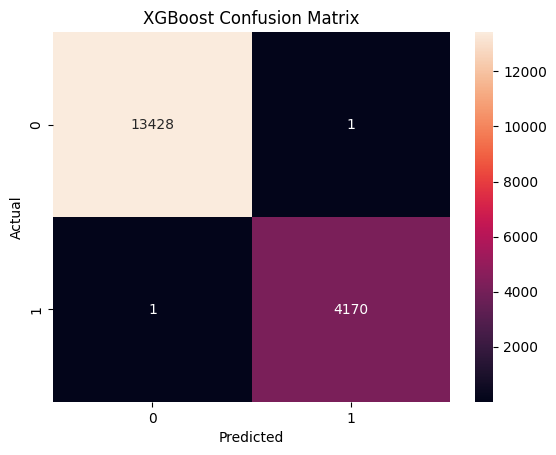


===== ISOLATION FOREST =====
Accuracy: 0.6934659090909091
              precision    recall  f1-score   support

           0       0.76      0.88      0.81     13429
           1       0.18      0.08      0.11      4171

    accuracy                           0.69     17600
   macro avg       0.47      0.48      0.46     17600
weighted avg       0.62      0.69      0.65     17600



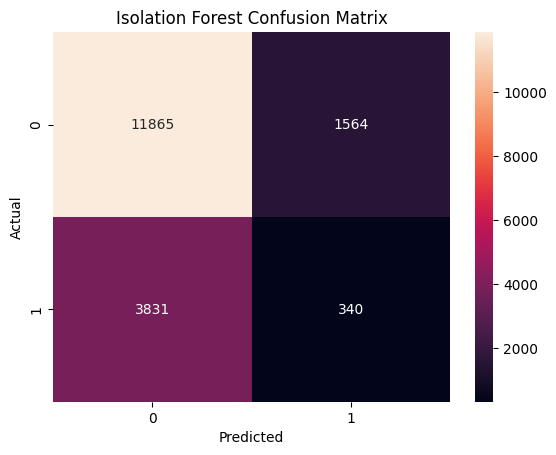


===== KMEANS =====
Accuracy: 0.7630113636363637
              precision    recall  f1-score   support

           0       0.76      1.00      0.87     13429
           1       0.00      0.00      0.00      4171

    accuracy                           0.76     17600
   macro avg       0.38      0.50      0.43     17600
weighted avg       0.58      0.76      0.66     17600



c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

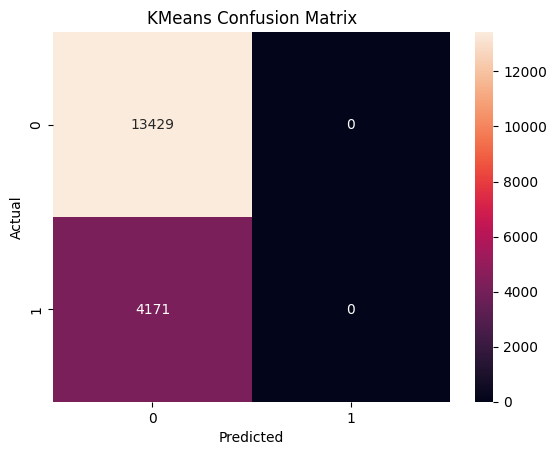

c:\Users\kalug\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:21:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== PCA + XGBOOST =====
Accuracy: 0.99875
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13429
           1       1.00      1.00      1.00      4171

    accuracy                           1.00     17600
   macro avg       1.00      1.00      1.00     17600
weighted avg       1.00      1.00      1.00     17600



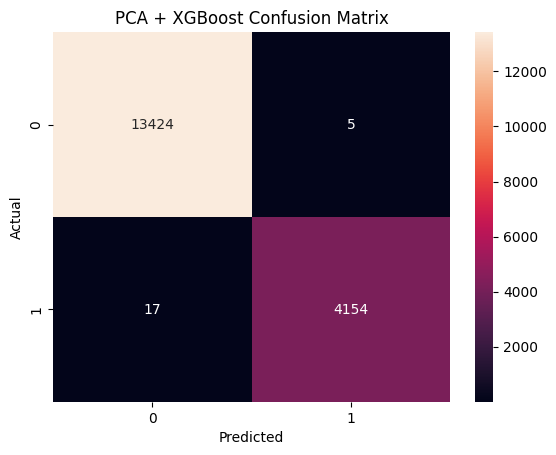

In [7]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode

# ================================
# STEP 1: LOAD FILES
# ================================
folder_path = "cicids2017/"
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

print("Files found:", files)

# ================================
# STEP 2: CHUNKING + CLEANING
# ================================
cleaned_chunks = []

for file in files:
    print(f"\nProcessing {file}...")
    
    file_path = os.path.join(folder_path, file)
    
    for chunk in pd.read_csv(file_path, chunksize=50000):
        
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        chunk.dropna(inplace=True)
        
        if 'Label' in chunk.columns:
            chunk.rename(columns={'Label': 'label'}, inplace=True)
        
        if 'label' in chunk.columns:
            chunk['label'] = chunk['label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
        
        chunk = chunk.sample(min(len(chunk), 2000), random_state=42)
        
        cleaned_chunks.append(chunk)

print("\nAll files processed!")

# ================================
# STEP 3: COMBINE
# ================================
df = pd.concat(cleaned_chunks, ignore_index=True)
print("Final dataset shape:", df.shape)

df.to_csv("cicids2017_final.csv", index=False)

# ================================
# STEP 4: PREPROCESS
# ================================
X = df.drop("label", axis=1)
y = df["label"]

X = X.select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)

y = y.loc[X.index]

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ================================
# STEP 5: TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# RANDOM FOREST
# ================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# XGBOOST
# ================================
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\n===== XGBOOST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure()
sns.heatmap(cm_xgb, annot=True, fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# ISOLATION FOREST
# ================================
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

y_pred_iso = iso.predict(X_test)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print("\n===== ISOLATION FOREST =====")
print("Accuracy:", accuracy_score(y_test, y_pred_iso))
print(classification_report(y_test, y_pred_iso))

cm_iso = confusion_matrix(y_test, y_pred_iso)
plt.figure()
sns.heatmap(cm_iso, annot=True, fmt="d")
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# KMEANS
# ================================
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)

y_pred_kmeans = kmeans.predict(X_test)

# Fix label mismatch
labels = np.zeros_like(y_pred_kmeans)
for i in range(2):
    mask = (y_pred_kmeans == i)
    labels[mask] = mode(y_test[mask], keepdims=True)[0]

print("\n===== KMEANS =====")
print("Accuracy:", accuracy_score(y_test, labels))
print(classification_report(y_test, labels))

cm_kmeans = confusion_matrix(y_test, labels)
plt.figure()
sns.heatmap(cm_kmeans, annot=True, fmt="d")
plt.title("KMeans Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# PCA + XGBOOST
# ================================
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

xgb_pca = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = xgb_pca.predict(X_test_pca)

print("\n===== PCA + XGBOOST =====")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_pca))
print(classification_report(y_test_pca, y_pred_pca))

cm_pca = confusion_matrix(y_test_pca, y_pred_pca)
plt.figure()
sns.heatmap(cm_pca, annot=True, fmt="d")
plt.title("PCA + XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()